# Operator Zoo

A tour of every operator type in gaussx, showing construction,
sizes, matvec, and how they compose.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## 1. Diagonal

The simplest operator. Lineax provides `DiagonalLinearOperator`
and gaussx gives it O(n) fast paths for every primitive.

In [2]:
d = jnp.array([1.0, 4.0, 9.0, 16.0])
D = lx.DiagonalLinearOperator(d)

print(f"Type:    {type(D).__name__}")
print(f"Size:    {D.in_size()} x {D.out_size()}")
print(f"mv([1,1,1,1]): {D.mv(jnp.ones(4))}")
print(f"solve:   {gaussx.solve(D, jnp.ones(4))}")
print(f"logdet:  {gaussx.logdet(D):.4f}")
print(f"trace:   {gaussx.trace(D):.1f}")

Type:    DiagonalLinearOperator
Size:    4 x 4
mv([1,1,1,1]): [ 1.  4.  9. 16.]
solve:   [1.         0.25       0.11111111 0.0625    ]


logdet:  6.3561
trace:   30.0


## 2. BlockDiag

Block diagonal from independent sub-operators.
Every primitive decomposes per-block.

In [3]:
A = lx.MatrixLinearOperator(jnp.array([[2.0, 0.5], [0.5, 3.0]]))
B = lx.DiagonalLinearOperator(jnp.array([1.0, 5.0, 7.0]))

BD = gaussx.BlockDiag(A, B)

print(f"Type:    {type(BD).__name__}")
print(f"Size:    {BD.in_size()} x {BD.out_size()}")
print(f"Blocks:  {len(BD.operators)}")
print(f"logdet:  {gaussx.logdet(BD):.4f}")
print(f"trace:   {gaussx.trace(BD):.1f}")

Type:    BlockDiag
Size:    5 x 5
Blocks:  2


logdet:  5.3045
trace:   18.0


## 3. Kronecker

$A \otimes B$ stored as two small matrices.
Matvec via Roth's column lemma, logdet/solve/cholesky per-factor.

In [4]:
K1 = lx.MatrixLinearOperator(jnp.array([[2.0, 0.5], [0.5, 3.0]]))
K2 = lx.MatrixLinearOperator(jnp.array([[1.0, 0.3], [0.3, 2.0]]))

K = gaussx.Kronecker(K1, K2)

print(f"Type:    {type(K).__name__}")
print(f"Size:    {K.in_size()} x {K.out_size()}")
print(f"Factors: {len(K.operators)}")
print(f"logdet:  {gaussx.logdet(K):.4f}")
print(f"trace:   {gaussx.trace(K):.1f}")

# 3-factor Kronecker
K3 = gaussx.Kronecker(K1, K2, lx.DiagonalLinearOperator(jnp.array([1.0, 2.0])))
print(f"\n3-factor Kronecker size: {K3.in_size()}")
print(f"3-factor logdet: {gaussx.logdet(K3):.4f}")

Type:    Kronecker
Size:    4 x 4
Factors: 2
logdet:  4.7926


trace:   15.0

3-factor Kronecker size: 8


3-factor logdet: 12.3578


## 4. LowRankUpdate

$L + U \mathrm{diag}(d) V^\top$. Woodbury solve, determinant lemma logdet.

In [5]:
base = lx.DiagonalLinearOperator(jnp.array([1.0, 2.0, 3.0, 4.0]))
U = jnp.array([[1.0, 0.0], [0.5, 0.5], [0.0, 1.0], [0.0, 0.0]])
d_vals = jnp.array([0.5, 0.3])

lr = gaussx.LowRankUpdate(base, U, d_vals)

print(f"Type:    {type(lr).__name__}")
print(f"Size:    {lr.in_size()} x {lr.out_size()}")
print(f"Rank:    {lr.rank}")
print(f"logdet:  {gaussx.logdet(lr):.4f}")

# Convenience constructors
lr2 = gaussx.low_rank_plus_diag(jnp.ones(4), U)
print(f"\nlow_rank_plus_diag rank: {lr2.rank}")
print(f"is_low_rank: {gaussx.is_low_rank(lr2)}")

Type:    LowRankUpdate
Size:    4 x 4
Rank:    2


logdet:  3.7519



low_rank_plus_diag rank: 2
is_low_rank: True


## 5. Visualizing operator structure

Let's visualize the sparsity pattern of each operator type.

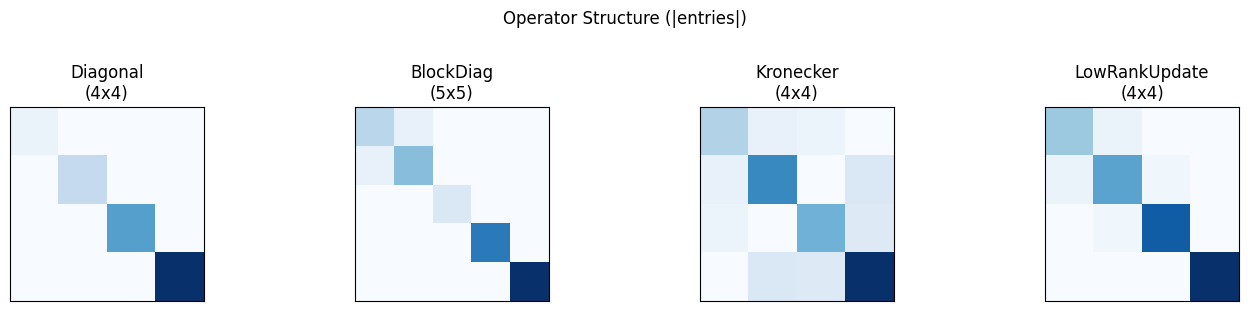

In [6]:
operators = {
    "Diagonal": D,
    "BlockDiag": BD,
    "Kronecker": K,
    "LowRankUpdate": lr,
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, op) in zip(axes, operators.items(), strict=False):
    mat = op.as_matrix()
    im = ax.imshow(jnp.abs(mat), cmap="Blues", interpolation="nearest")
    ax.set_title(f"{name}\n({op.in_size()}x{op.out_size()})")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Operator Structure (|entries|)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Composition with lineax arithmetic

gaussx operators compose with lineax's `+`, `@`, `*` operators.

In [7]:
# Kronecker + diagonal perturbation
D_small = lx.DiagonalLinearOperator(0.1 * jnp.ones(4))
perturbed = K + D_small
print(f"K + 0.1*I type: {type(perturbed).__name__}")
print(
    f"(K + 0.1*I).mv == K.mv + 0.1*v: "
    f"{jnp.allclose((K + D_small).mv(jnp.ones(4)), K.mv(jnp.ones(4)) + 0.1)}"
)

# Scalar multiplication
scaled = K * 2.0
print(f"2*K type: {type(scaled).__name__}")

K + 0.1*I type: AddLinearOperator


(K + 0.1*I).mv == K.mv + 0.1*v: True
2*K type: MulLinearOperator


## 7. Tag queries

Every operator carries structural tags that gaussx uses for dispatch.

In [8]:
print("Diagonal:")
print(f"  is_symmetric:  {gaussx.is_symmetric(D)}")
print(f"  is_diagonal:   {gaussx.is_diagonal(D)}")

print("\nKronecker:")
print(f"  is_kronecker:  {gaussx.is_kronecker(K)}")
print(f"  is_symmetric:  {gaussx.is_symmetric(K)}")

print("\nBlockDiag:")
print(f"  is_block_diagonal: {gaussx.is_block_diagonal(BD)}")

print("\nLowRankUpdate:")
print(f"  is_low_rank:   {gaussx.is_low_rank(lr)}")

Diagonal:
  is_symmetric:  True
  is_diagonal:   True

Kronecker:
  is_kronecker:  True
  is_symmetric:  False

BlockDiag:
  is_block_diagonal: True

LowRankUpdate:
  is_low_rank:   True


## Summary

| Operator | Storage | mv cost | Key identity |
|----------|---------|---------|-------------|
| `Diagonal` | O(n) | O(n) | Built into lineax |
| `BlockDiag` | sum O(n_i^2) | sum O(n_i^2) | Per-block decomposition |
| `Kronecker` | sum O(n_i^2) | O(sum n_i^3) | Roth's column lemma |
| `LowRankUpdate` | O(nk) | O(nk) | Woodbury identity |